In [1]:
import pandas as pd

df = pd.read_csv("../data/mart/variant_13/mart_yearly.csv")

df.head()

,country_name,country_name_full,region,income_level,year,value,value_prev,value_diff,growth_rate,trend,rolling_avg_3
0,South Africa,Republic of South Africa,Africa,Upper middle income,1991,23.137,NaN,NaN,NaN,no_change,NaN
1,South Africa,Republic of South Africa,Africa,Upper middle income,1992,23.463,23.137,0.326,1.408999,growth,NaN
2,South Africa,Republic of South Africa,Africa,Upper middle income,1993,23.361,23.463,-0.102,-0.434727,decline,23.320333
3,South Africa,Republic of South Africa,Africa,Upper middle income,1994,23.067,23.361,-0.294,-1.258508,decline,23.297000
4,South Africa,Republic of South Africa,Africa,Upper middle income,1995,22.705,23.067,-0.362,-1.569341,decline,23.044333


In [2]:
df = df.dropna()

df.shape

(33, 11)

In [3]:
features = [
    "value_prev",
    "value_diff",
    "growth_rate",
    "rolling_avg_3"
]

target = "value"

X = df[features]
y = df[target]

split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd

df = pd.read_csv("../data/mart/variant_13/mart_yearly.csv")

X = df[["year"]]
y = df["value"]

# Для временного ряда лучше без случайного перемешивания
split_idx = int(len(df) * 0.8)

train = df.iloc[:split_idx].copy()
test = df.iloc[split_idx:].copy()

X_train = train[["year"]]
y_train = train["value"]

X_test = test[["year"]]
y_test = test["value"]

model = LinearRegression()
model.fit(X_train, y_train)

test["prediction"] = model.predict(X_test)

test.head()

,country_name,country_name_full,region,income_level,year,value,value_prev,value_diff,growth_rate,trend,rolling_avg_3,prediction
28,South Africa,Republic of South Africa,Africa,Upper middle income,2019,28.468,26.906,1.562,5.805397,growth,27.469667,25.474063
29,South Africa,Republic of South Africa,Africa,Upper middle income,2020,29.217,28.468,0.749,2.631024,growth,28.197000,25.600940
30,South Africa,Republic of South Africa,Africa,Upper middle income,2021,34.007,29.217,4.790,16.394565,growth,30.564000,25.727816
31,South Africa,Republic of South Africa,Africa,Upper middle income,2022,33.268,34.007,-0.739,-2.173082,decline,32.164000,25.854692
32,South Africa,Republic of South Africa,Africa,Upper middle income,2023,32.098,33.268,-1.170,-3.516893,decline,33.124333,25.981569


In [13]:
predictions = pd.DataFrame({
    "actual": y_test,
    "predicted": pred
})

predictions


predictions.to_csv(
    "../docs/ml/predictions_sample.csv",
    index=False
)

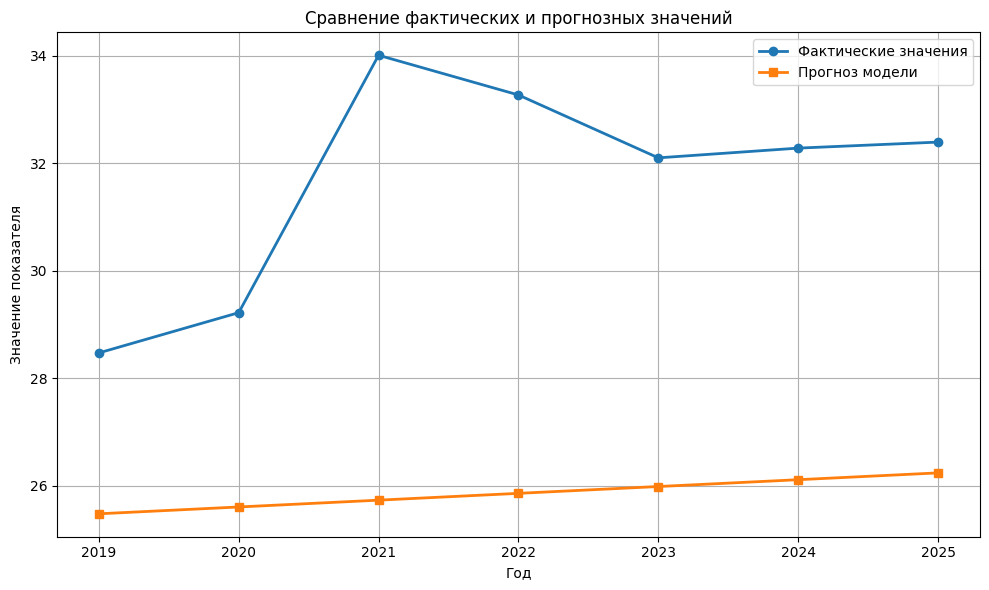

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    test["year"],
    test["value"],
    marker="o",
    linewidth=2,
    label="Фактические значения"
)

plt.plot(
    test["year"],
    test["prediction"],
    marker="s",
    linewidth=2,
    label="Прогноз модели"
)

plt.title("Сравнение фактических и прогнозных значений")
plt.xlabel("Год")
plt.ylabel("Значение показателя")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("../docs/ml/metrics.png")
plt.show()